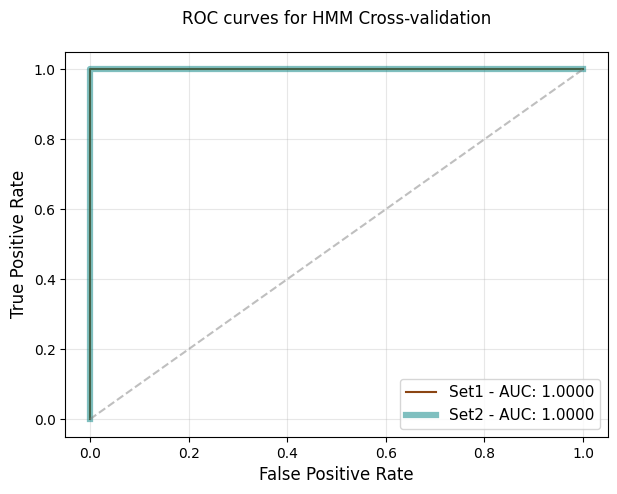

In [2]:
#ROC Curve
import re
import numpy as np
import pandas as pd
from sys import argv
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from sklearn.metrics import roc_curve, auc  

def get_roc_data(filename):
    df = pd.read_csv(filename, sep='\t', header=None, names=['id', 'evalue', 'label'])
    #E-values are log-transformed to convert small probability values into positive significance scores,where higher values represent more confident predictions.
    scores = -np.log10(df['evalue'] + 1e-200) 
    fpr, tpr, _ = roc_curve(df['label'], scores)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr1, tpr1, auc1 = get_roc_data('kunitz_set_1.txt')
fpr2, tpr2, auc2 = get_roc_data('kunitz_set_2.txt')

plt.figure(figsize=(7, 5))
plt.plot(fpr1, tpr1, color='#8b4513', lw=1.5, label=f'Set1 - AUC: {auc1:.4f}')
plt.plot(fpr2, tpr2, color='#008080', lw=4.5, alpha=0.5, label=f'Set2 - AUC: {auc2:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)

plt.title('ROC curves for HMM Cross-validation', fontsize=12, pad=20)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.2)
plt.grid(alpha=0.3)
plt.savefig('ROC_curves.png', dpi=300)
plt.show()